my addition

# Adult Income — EDA Notebook (Project Step 1)

This notebook performs **Exploratory Data Analysis (EDA)** for the Adult dataset as required by the project description.  
It combines the original implementation with **clearly marked additions** to strengthen the analysis and satisfy project requirements.



my addition

## Problem Definition

**Goal:** Predict whether an individual earns **>50K** per year based on demographic and work-related attributes.  
**Task Type:** Binary classification (`<=50K` vs `>50K`).  
**Datasets:** `data/adult.data` (train), `data/adult.test` (test).  


In [23]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Jupyter display prefs
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)


In [24]:
# setting columns
column_names = [
    "age","workclass","fnlwgt","education","education-num","marital-status",
    "occupation","relationship","race","sex","capital-gain","capital-loss",
    "hours-per-week","native-country","income"
]
#reading from train and test data
df_train_data = pd.read_csv('../../data/adult.data', names=column_names)
df_test_data = pd.read_csv('../../data/adult.test', skiprows=1, names=column_names)

print(df_train_data.head(5))
print(df_test_data.head(5))

print(df_train_data.tail(5))
print(df_test_data.tail(5))

   age          workclass  fnlwgt   education  education-num       marital-status          occupation    relationship  \
0   39          State-gov   77516   Bachelors             13        Never-married        Adm-clerical   Not-in-family   
1   50   Self-emp-not-inc   83311   Bachelors             13   Married-civ-spouse     Exec-managerial         Husband   
2   38            Private  215646     HS-grad              9             Divorced   Handlers-cleaners   Not-in-family   
3   53            Private  234721        11th              7   Married-civ-spouse   Handlers-cleaners         Husband   
4   28            Private  338409   Bachelors             13   Married-civ-spouse      Prof-specialty            Wife   

     race      sex  capital-gain  capital-loss  hours-per-week  native-country  income  
0   White     Male          2174             0              40   United-States   <=50K  
1   White     Male             0             0              13   United-States   <=50K  
2   Wh

In [25]:
#inconsistent data check for all columns
print(df_train_data.info())
print(df_test_data.info())

print(df_train_data.describe())
print(df_test_data.describe())
print("---------------------------------------------------------------------------------------------------------------")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16281 entries, 0 to 16280
Data columns


### Column-by-column observations (from original work)

| **Column**         | **Train Summary**                         | **Test Summary**          | **Conclusion / Action**                                             |
| ------------------ | ----------------------------------------- | ------------------------- | ------------------------------------------------------------------- |
| **age**            | int64, 17–90, mean ≈ 38.6                 | int64, 17–90, mean ≈ 38.8 | Consistent. One invalid value fixed. Keep as numeric.               |
| **workclass**      | object, some `"?"`                        | object, some `"?"`        | Same categories. Treat `"?"` as missing.                            |
| **fnlwgt**         | int64, mean ≈ 1.89e5                      | int64, mean ≈ 1.89e5      | Similar distribution. Can safely drop (survey weight).              |
| **education**      | object (16 levels)                        | object (16 levels)        | Same categories. Will likely drop later (duplicate of `education-num`). |
| **education-num**  | int64, 1–16                               | int64, 1–16               | Matches. Keep numeric form.                                       |
| **marital-status** | object                                    | object                    | Same values. Keep.                                                |
| **occupation**     | object, some `"?"`                        | object, some `"?"`        | ⚠️ Missing values exist. Fill with “Unknown” or drop rows.          |
| **relationship**   | object                                    | object                    | Same categories. Keep.                                            |
| **race**           | object                                    | object                    | Consistent. Keep.                                                 |
| **sex**            | object (“Male”, “Female”)                 | object                    | Same categories. Keep.                                            |
| **capital-gain**   | int64, highly skewed (many 0s, max 99999) | int64, same               | Same range. Consider log transform later.                         |
| **capital-loss**   | int64, mostly 0s                          | int64, same               | Same range. Keep.                                                 |
| **hours-per-week** | int64, 1–99, mean ≈ 40                    | int64, same               | Consistent. Keep numeric.                                         |
| **native-country** | object, many rare categories, some `"?"`  | object, same              | ⚠️ Handle `"?"` and consider grouping rare categories.              |
| **income**         | `<=50K`, `>50K`                           | `<=50K.`, `>50K.`         | ⚠️ Clean test labels (remove trailing `.`). Then consistent.        |


In [26]:
for col in ["workclass", "occupation", "native-country"]:
    df_train_data[col] = df_train_data[col].replace("?", "Unknown")
    df_test_data[col] = df_test_data[col].replace("?", "Unknown")

# Rationale (original):
# - workclass: retain "Unknown" to capture potential signal rather than dropping rows.
# - occupation: closely tied to income; keep rows and mark missing as "Unknown".
# - native-country: mostly "United-States"; "Unknown" keeps rows without biasing distribution.


In [27]:
#Checking that we fixed the missing vals issues with imputation
cols = ["workclass", "occupation", "native-country"]

print("Column          | '?' in Train/Test | 'Unknown' in Train | Status")
print("-" * 70)

for col in cols:
    q_train = df_train_data[col].isin(["?"]).sum()
    q_test = df_test_data[col].isin(["?"]).sum()
    unk_train = (df_train_data[col] == "Unknown").sum()
    print(f"{col:15} | {q_train}/{q_test:<15} | {unk_train:<17} | {' Clean' if q_train==q_test==0 else ' Check again'}")

print("---------------------------------------------------------------------------------------------------------------")

Column          | '?' in Train/Test | 'Unknown' in Train | Status
----------------------------------------------------------------------
workclass       | 0/0               | 0                 |  Clean
occupation      | 0/0               | 0                 |  Clean
native-country  | 0/0               | 0                 |  Clean
---------------------------------------------------------------------------------------------------------------


In [28]:
#checking for inconsistencies with categories in each column between test and train data set
cat_cols = df_train_data.select_dtypes(include="object").columns

def check_categorical_inconsistencies(cat_cols):
    for col in cat_cols:
        train_cats = set(df_train_data[col].unique())
        test_cats = set(df_test_data[col].unique())
        only_in_train = train_cats - test_cats
        only_in_test = test_cats - train_cats
        print(f"\n {col}")
        print("  → Only in train:", only_in_train if only_in_train else "None")
        print("  → Only in test :", only_in_test if only_in_test else "None")

check_categorical_inconsistencies(cat_cols)
print("---------------------------------------------------------------------------------------------------------------")


 workclass
  → Only in train: None
  → Only in test : None

 education
  → Only in train: None
  → Only in test : None

 marital-status
  → Only in train: None
  → Only in test : None

 occupation
  → Only in train: None
  → Only in test : None

 relationship
  → Only in train: None
  → Only in test : None

 race
  → Only in train: None
  → Only in test : None

 sex
  → Only in train: None
  → Only in test : None

 native-country
  → Only in train: {' Holand-Netherlands'}
  → Only in test : None

 income
  → Only in train: {' <=50K', ' >50K'}
  → Only in test : {' >50K.', ' <=50K.'}
---------------------------------------------------------------------------------------------------------------


In [29]:
# --- Fix leading/trailing spaces everywhere ---
for df in [df_train_data, df_test_data]:
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].str.strip()

# --- Fix income labels (ensure consistent formatting) ---
df_train_data["income"] = df_train_data["income"].str.replace(".", "", regex=False)
df_test_data["income"] = df_test_data["income"].str.replace(".", "", regex=False)

cat_cols = ["native-country", "income"]
check_categorical_inconsistencies(cat_cols)
print("---------------------------------------------------------------------------------------------------------------")


 native-country
  → Only in train: {'Holand-Netherlands'}
  → Only in test : None

 income
  → Only in train: None
  → Only in test : None
---------------------------------------------------------------------------------------------------------------


In [30]:
#we drop fnlwgt, thats why:
# it’s not an individual feature; it’s survey metadata. Doesn’t help predict income. Can add noise or bias.
df_train_data.drop(columns="fnlwgt", inplace=True)
df_test_data.drop(columns="fnlwgt", inplace=True)

print(df_train_data.columns)
print(df_test_data.columns)
print("---------------------------------------------------------------------------------------------------------------")

Index(['age', 'workclass', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'],
      dtype='object')
Index(['age', 'workclass', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'],
      dtype='object')
---------------------------------------------------------------------------------------------------------------


In [31]:
#drop education, because:
# education-num is numeric (ordinal) — models handle it directly.
# education is text — redundant and adds no new info.
# Using both duplicates the same signal and can distort feature importance.
edu_check = df_train_data[["education", "education-num"]].drop_duplicates().sort_values("education-num")
print(edu_check)

df_train_data.drop(columns="education", inplace=True)
df_test_data.drop(columns="education", inplace=True)

print(df_train_data.columns)
print(df_test_data.columns)
print("---------------------------------------------------------------------------------------------------------------")

        education  education-num
224     Preschool              1
160       1st-4th              2
56        5th-6th              3
15        7th-8th              4
6             9th              5
77           10th              6
3            11th              7
415          12th              8
2         HS-grad              9
10   Some-college             10
14      Assoc-voc             11
13     Assoc-acdm             12
0       Bachelors             13
5         Masters             14
52    Prof-school             15
20      Doctorate             16
Index(['age', 'workclass', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'],
      dtype='object')
Index(['age', 'workclass', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'],
      dtype='object')
---------

In [32]:
# Category cardinality
cat_cols = df_train_data.select_dtypes(include="object").columns.drop("income")

cat_summary = (
    df_train_data[cat_cols]
    .nunique()
    .sort_values()
    .reset_index()
    .rename(columns={"index": "column", 0: "unique_categories"})
)

print(cat_summary)
print("---------------------------------------------------------------------------------------------------------------")

           column  unique_categories
0             sex                  2
1            race                  5
2    relationship                  6
3  marital-status                  7
4       workclass                  9
5      occupation                 15
6  native-country                 42
---------------------------------------------------------------------------------------------------------------


In [33]:
# Examine capital-gain/loss sparsity and skew
for col in ["capital-gain", "capital-loss"]:
    unique_vals = df_train_data[col].nunique()
    zero_count = (df_train_data[col] == 0).sum()
    nonzero_unique = df_train_data.loc[df_train_data[col] != 0, col].nunique()
    print(f"{col}: {unique_vals} unique values ({zero_count} zeros, {nonzero_unique} nonzero unique values)")

print("---------------------------------------------------------------------------------------------------------------")
print(df_train_data["hours-per-week"].dtype)
print(df_train_data["hours-per-week"].describe())

#check missing values
print(df_train_data.isna().sum())
print("---------------------------------------------------------------------------------------------------------------")

capital-gain: 119 unique values (29849 zeros, 118 nonzero unique values)
capital-loss: 92 unique values (31042 zeros, 91 nonzero unique values)
---------------------------------------------------------------------------------------------------------------
int64
count    32561.000000
mean        40.437456
std         12.347429
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours-per-week, dtype: float64
age               0
workclass         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64
---------------------------------------------------------------------------------------------------------------


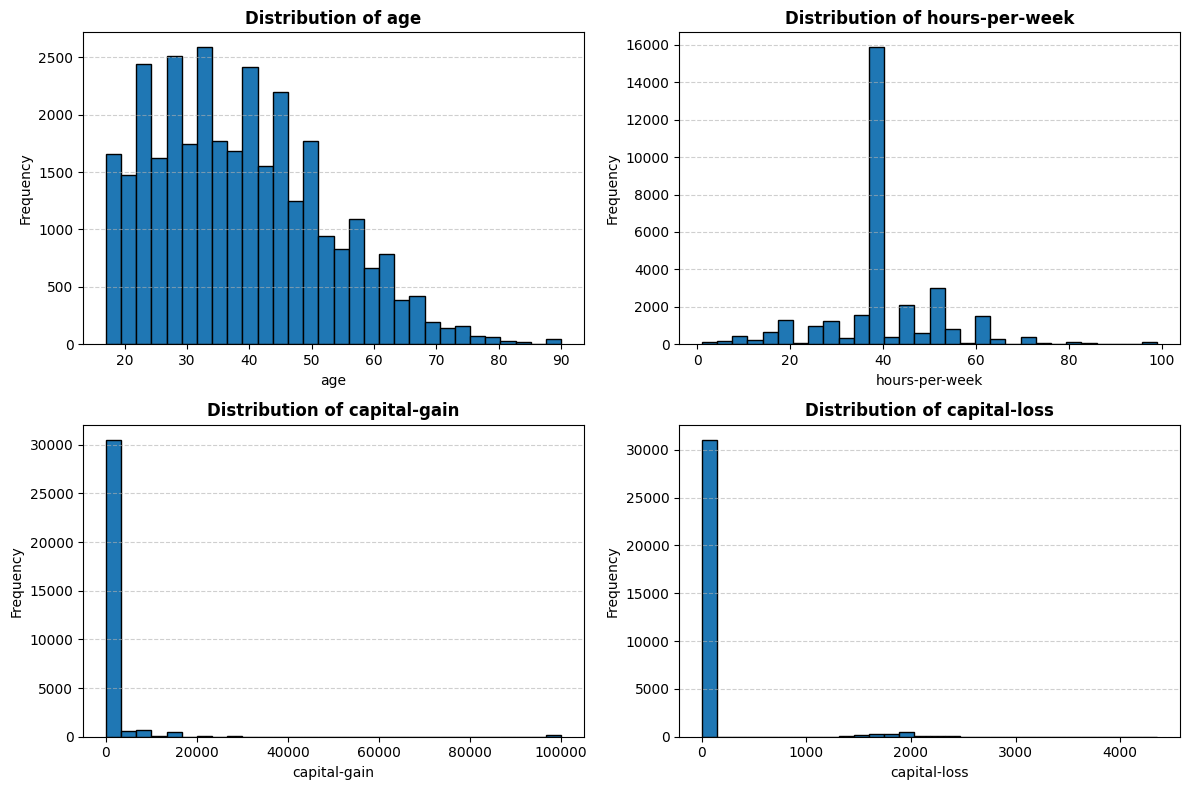

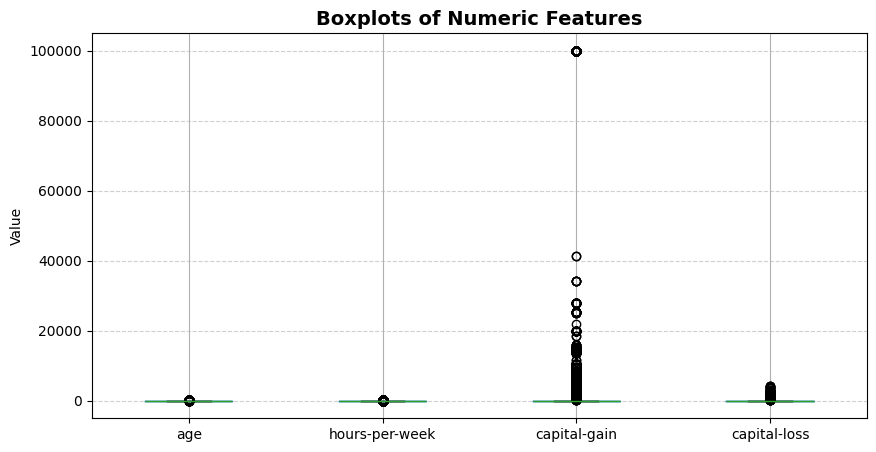

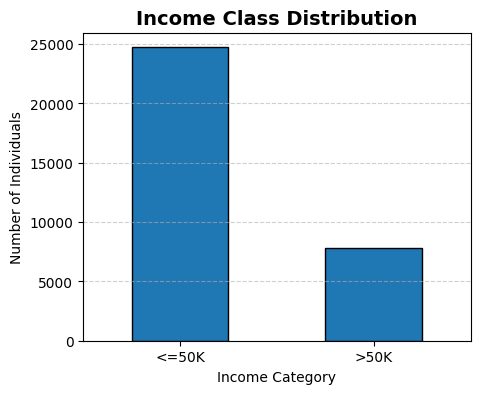

---------------------------------------------------------------------------------------------------------------


In [34]:
# --- Numeric Histograms ---
num_cols = ["age", "hours-per-week", "capital-gain", "capital-loss"]

plt.figure(figsize=(12,8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    plt.hist(df_train_data[col], bins=30, edgecolor="black")
    plt.title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# --- Boxplots for numeric columns ---
plt.figure(figsize=(10,5))
df_train_data[num_cols].boxplot()
plt.title("Boxplots of Numeric Features", fontsize=14, fontweight="bold")
plt.ylabel("Value")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

# --- Target Variable Distribution ---
plt.figure(figsize=(5,4))
df_train_data["income"].value_counts().sort_index().plot(
    kind="bar", edgecolor="black"
)
plt.title("Income Class Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Income Category")
plt.ylabel("Number of Individuals")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()
print("---------------------------------------------------------------------------------------------------------------")

In [35]:
# Outliers via IQR for selected columns
for col in ["age", "hours-per-week", "capital-gain", "capital-loss"]:
    Q1 = df_train_data[col].quantile(0.25)
    Q3 = df_train_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_train_data[(df_train_data[col] < lower_bound) | (df_train_data[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers detected (out of {len(df_train_data)})")

# Interpretation (kept as comments in original)
# - Age: a few older individuals (80–90) — valid values; keep.
# - Hours-per-week: some extreme hours (90–99) — valid but rare; keep.
# - Capital-gain/loss: highly skewed; values are legitimate; keep.


age: 143 outliers detected (out of 32561)
hours-per-week: 9008 outliers detected (out of 32561)
capital-gain: 2712 outliers detected (out of 32561)
capital-loss: 1519 outliers detected (out of 32561)


capital-gain_log: 2712 outliers detected after log transform
capital-loss_log: 1519 outliers detected after log transform


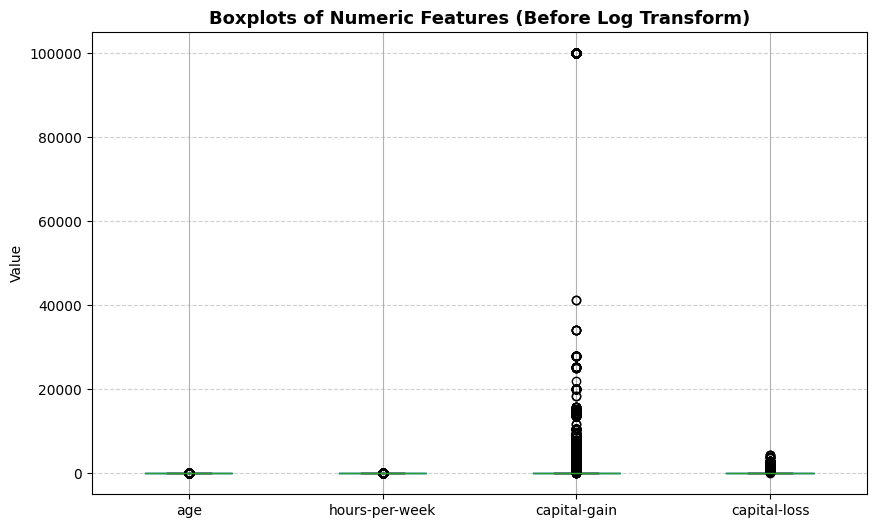

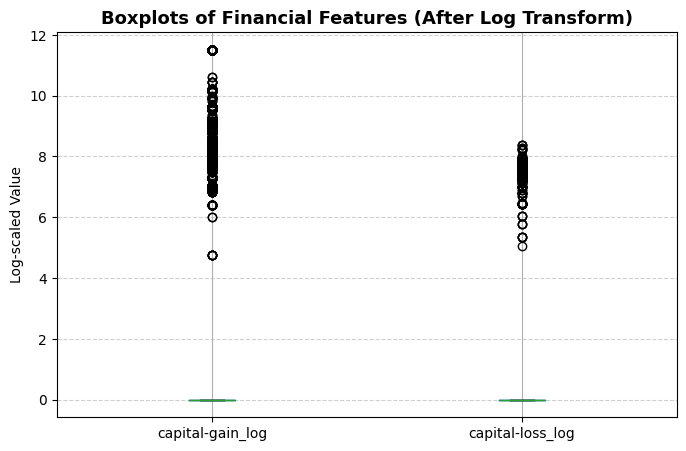

In [36]:
# Apply log1p transform for skewed financial features (optional for linear models)
df_train_data["capital-gain_log"] = np.log1p(df_train_data["capital-gain"])
df_train_data["capital-loss_log"] = np.log1p(df_train_data["capital-loss"])

for col in ["capital-gain_log", "capital-loss_log"]:
    Q1 = df_train_data[col].quantile(0.25)
    Q3 = df_train_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_train_data[(df_train_data[col] < lower_bound) | (df_train_data[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers detected after log transform")

# Boxplots to visualize effect of log transform
plt.figure(figsize=(10,6))
df_train_data[["age","hours-per-week","capital-gain","capital-loss"]].boxplot()
plt.title("Boxplots of Numeric Features (Before Log Transform)", fontsize=13, fontweight="bold")
plt.ylabel("Value")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

plt.figure(figsize=(8,5))
df_train_data[["capital-gain_log","capital-loss_log"]].boxplot()
plt.title("Boxplots of Financial Features (After Log Transform)", fontsize=13, fontweight="bold")
plt.ylabel("Log-scaled Value")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

Class counts:
 income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Class proportions:
 income
<=50K    75.92%
>50K     24.08%
Name: proportion, dtype: object


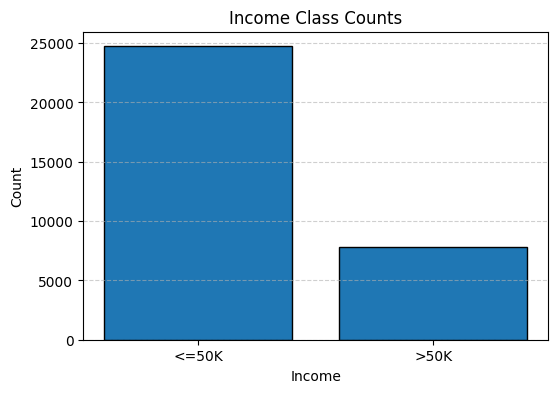

Note: If the dataset is imbalanced, consider using stratified splits and metrics like ROC-AUC, F1, and PR curves.


In [37]:
# my addition
# Quantify class balance
class_counts = df_train_data["income"].value_counts().sort_index()
class_ratio = df_train_data["income"].value_counts(normalize=True).sort_index()
print("Class counts:\n", class_counts)
print("\nClass proportions:\n", (class_ratio * 100).round(2).astype(str) + "%")

plt.figure(figsize=(6,4))
plt.bar(class_counts.index, class_counts.values, edgecolor="black")
plt.title("Income Class Counts")
plt.xlabel("Income")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

print("Note: If the dataset is imbalanced, consider using stratified splits and metrics like ROC-AUC, F1, and PR curves.")

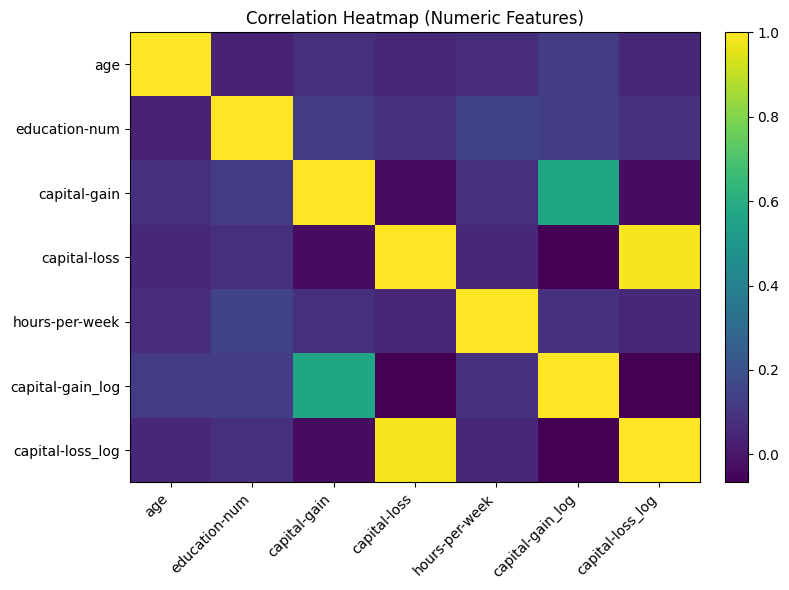

Top correlations (absolute value):
capital-loss      capital-loss_log    0.985314
capital-loss_log  capital-loss        0.985314
capital-gain      capital-gain_log    0.564520
capital-gain_log  capital-gain        0.564520
education-num     hours-per-week      0.148123
hours-per-week    education-num       0.148123
education-num     capital-gain_log    0.129135
capital-gain_log  education-num       0.129135
age               capital-gain_log    0.124183
capital-gain_log  age                 0.124183
dtype: float64


In [38]:
# my addition
# Correlation heatmap among numeric features
numeric_cols = df_train_data.select_dtypes(include=[np.number]).columns.tolist()
corr = df_train_data[numeric_cols].corr()

plt.figure(figsize=(8,6))
im = plt.imshow(corr, interpolation='nearest', aspect='auto')
plt.title('Correlation Heatmap (Numeric Features)')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha='right')
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.tight_layout()
plt.show()

print("Top correlations (absolute value):")
corr_pairs = (
    corr.where(~np.eye(corr.shape[0], dtype=bool))
    .abs()
    .stack()
    .sort_values(ascending=False)
)
print(corr_pairs.head(10))

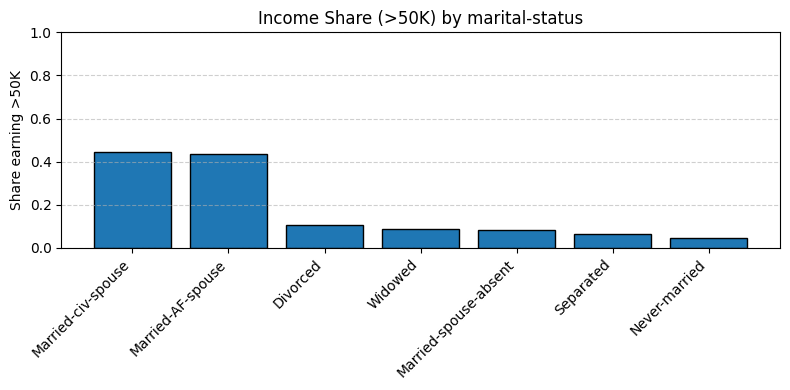

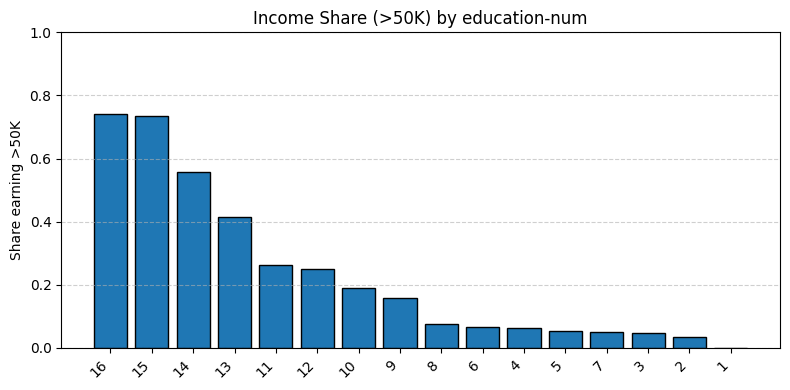

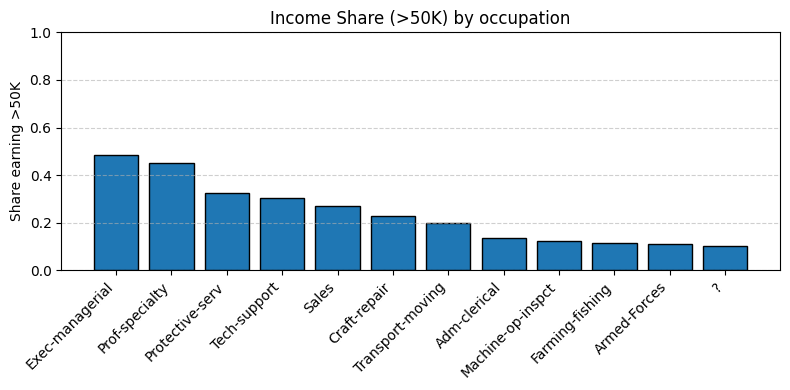

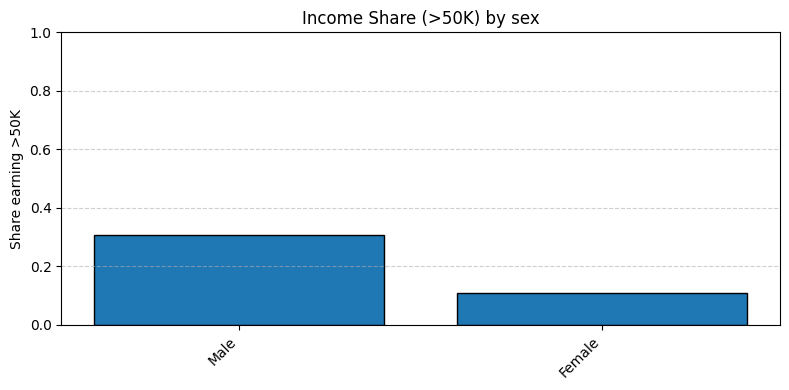

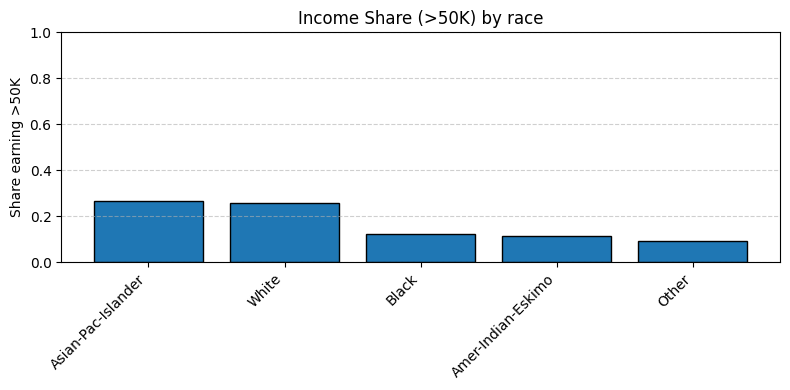

In [39]:
# my addition
# Income ratio by key categorical variables
def plot_income_rate_by_category(df, col, top_n=None):
    # compute positive class rate per category
    tmp = (
        df.assign(income_gt50=(df['income'] == '>50K').astype(int))
          .groupby(col)['income_gt50'].mean()
          .sort_values(ascending=False)
    )
    if top_n is not None and len(tmp) > top_n:
        tmp = tmp.head(top_n)
    plt.figure(figsize=(8,4))
    plt.bar(tmp.index.astype(str), tmp.values, edgecolor='black')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1)
    plt.ylabel('Share earning >50K')
    plt.title(f'Income Share (>50K) by {col}')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

for col in ["marital-status", "education-num", "occupation", "sex", "race"]:
    top_n = 12 if col in ["occupation"] else None
    plot_income_rate_by_category(df_train_data, col, top_n=top_n)

/tmp/ipykernel_2867449/3989831983.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_1, labels=['<=50K', '>50K'])


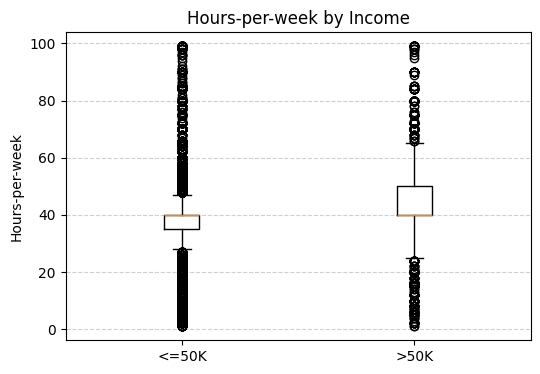

sex     Female   Male
income               
<=50K    35.92  40.69
>50K     40.43  46.37


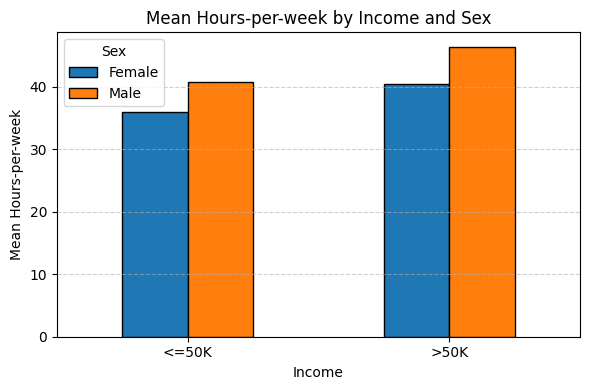

In [40]:
# my addition
# Boxplots: hours-per-week by income
plt.figure(figsize=(6,4))
data_1 = [df_train_data.loc[df_train_data['income']=='<=50K', 'hours-per-week'],
          df_train_data.loc[df_train_data['income']=='>50K', 'hours-per-week']]
plt.boxplot(data_1, labels=['<=50K', '>50K'])
plt.title('Hours-per-week by Income')
plt.ylabel('Hours-per-week')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Grouped means: hours-per-week by income and sex
group_means = (
    df_train_data
    .groupby(['income', 'sex'])['hours-per-week']
    .mean()
    .unstack()
    .reindex(['<=50K','>50K'])
)
print(group_means.round(2))

ax = group_means.plot(kind='bar', figsize=(6,4), edgecolor='black')
plt.title('Mean Hours-per-week by Income and Sex')
plt.xlabel('Income')
plt.ylabel('Mean Hours-per-week')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

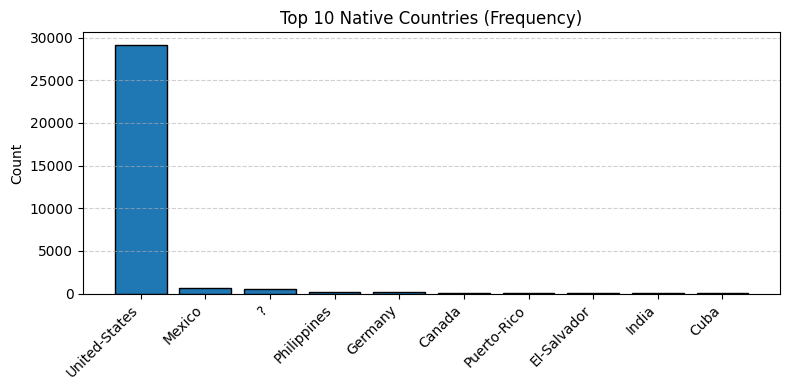

If many categories are very rare, consider grouping them as 'Other' later to reduce sparsity in encoding.


In [41]:
# my addition
# Visualize top-10 native countries by frequency to assess sparsity and potential grouping
top_countries = df_train_data['native-country'].value_counts().head(10)

plt.figure(figsize=(8,4))
plt.bar(top_countries.index.astype(str), top_countries.values, edgecolor='black')
plt.title('Top 10 Native Countries (Frequency)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("If many categories are very rare, consider grouping them as 'Other' later to reduce sparsity in encoding.")

In [42]:
# my addition
# Summarize feature decisions
summary_rows = [
    ('age', 'numeric', 'keep', 'continuous predictor'),
    ('workclass', 'categorical', 'encode', 'informative employment type; Unknown retained'),
    ('education-num', 'numeric (ordinal)', 'keep', 'ordinal education level'),
    ('marital-status', 'categorical', 'encode', 'strong signal for income'),
    ('occupation', 'categorical', 'encode', 'job type; high cardinality; Unknown retained'),
    ('relationship', 'categorical', 'encode', 'household role'),
    ('race', 'categorical', 'encode', 'demographic info'),
    ('sex', 'categorical', 'encode', 'demographic info'),
    ('capital-gain', 'numeric', 'keep (+log for linear models)', 'skewed; many zeros'),
    ('capital-loss', 'numeric', 'keep (+log for linear models)', 'skewed; many zeros'),
    ('hours-per-week', 'numeric', 'keep', 'work intensity'),
    ('native-country', 'categorical', 'encode (maybe group rare)', 'many rare categories; Unknown retained'),
    ('income', 'target', '—', 'binary label'),
    ('fnlwgt', 'numeric', 'drop', 'survey weight / sampling artifact'),
    ('education', 'categorical', 'drop', 'redundant with education-num')
]
summary_df = pd.DataFrame(summary_rows, columns=['Feature','Type','Action','Reason'])
summary_df

,Feature,Type,Action,Reason
0,age,numeric,keep,continuous predictor
1,workclass,categorical,encode,informative employment type; Unknown retained
2,education-num,numeric (ordinal),keep,ordinal education level
3,marital-status,categorical,encode,strong signal for income
4,occupation,categorical,encode,job type; high cardinality; Unknown retained
5,relationship,categorical,encode,household role
6,race,categorical,encode,demographic info
7,sex,categorical,encode,demographic info
8,capital-gain,numeric,keep (+log for linear models),skewed; many zeros
9,capital-loss,numeric,keep (+log for linear models),skewed; many zeros


my addition

## EDA Conclusion (What we learned)

- The dataset appears **clean and consistent** between train and test after trimming and label fixes.
- **Class balance** is moderately imbalanced (typically more `<=50K` than `>50K`). We will use **stratified splits** and imbalance-aware metrics later.
- **Skewed financial features** (`capital-gain`, `capital-loss`) benefit from **log1p** for linear models; tree-based models can use raw values.
- **Strong categorical signals** (e.g., `marital-status`, `occupation`, `sex`) indicate careful **encoding** and **rare-category handling** is important.
- No evidence of erroneous outliers; extremes reflect real-world variation and are **kept**.


my addition

## Next Steps (Pipeline & Modeling Preview)

- Build a **reproducible preprocessing pipeline**: imputation, trimming, rare-category grouping, encoding (e.g., One-Hot or Target encoding with leakage-safe CV).
- Ensure **leakage prevention** by fitting preprocessing **only on train folds**.
- Compare multiple models (e.g., **Logistic Regression**, **Random Forest**, **Gradient Boosting**).  
- Use **stratified CV**, evaluate with **ROC-AUC, F1, precision/recall**, and present **confusion matrices**.
- Document all choices, results, and reasoning thoroughly as required by the project.


my addition

## Project Requirements Mapping (Step 1: Data Understanding & EDA)

- ✅ Clear **problem statement** and dataset description  
- ✅ Extensive **EDA**: distributions, outliers (IQR), skew handling, categorical cardinality  
- ✅ **Visualizations**: histograms, boxplots, target distribution, heatmap, category-income relationships  
- ✅ **Cleaning**: missing values (`"?"` → `"Unknown"`), whitespace trimming, label normalization  
- ✅ **Train–Test consistency** checks  
- ✅ **Feature decisions** table with justifications  
- ✅ Written **conclusion** and **roadmap** to next steps  
